In [1]:

# ===== Imports & Configurations
import os, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
try:
    from xgboost import XGBClassifier
except Exception:
    XGBClassifier = None

# imbalanced pipeline
try:
    from imblearn.pipeline import Pipeline
    from imblearn.over_sampling import SMOTE
except Exception:
    Pipeline = None
    SMOTE = None

import joblib
import shap

RANDOM_STATE = 42


In [2]:

#Load Dataset
DATA_PATH = 'C:\\Users\\KIIT\\Desktop\\Project\\creditcard.csv' 
MODEL_DIR = 'models'
os.makedirs(MODEL_DIR, exist_ok=True)

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Update DATA_PATH to the location of your creditcard.csv. Tried: {DATA_PATH}")
print('DATA_PATH ok:', DATA_PATH)


DATA_PATH ok: C:\Users\KIIT\Desktop\Project\creditcard.csv


In [3]:

# ===== Load dataset & Basic EDA =====
df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)
display(df.head())

print('\nColumns:', df.columns.tolist())
print('\nClass distribution:')
print(df['Class'].value_counts())
print('\nClass percentages:')
print((df['Class'].value_counts(normalize=True)*100).round(4))

# Optional quick plots (uncomment to display)
# plt.figure(figsize=(6,4))
# sns.countplot(x='Class', data=df)
# plt.title('Class distribution')
# plt.show()


Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Class percentages:
Class
0    99.8273
1     0.1727
Name: proportion, dtype: float64


In [4]:

# ===== Features & Labels =====
X = df.drop('Class', axis=1)
y = df['Class']

# Train-test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)


Train shape: (227845, 30) Test shape: (56962, 30)



## Scaling note
We will use `StandardScaler` inside the pipeline where appropriate. For demonstration, we *do not* apply PCA (the dataset's V1..V28 are already PCA-like). Pipelines will ensure transformations are fit only on training data to avoid leakage.


In [5]:

# ===== Build Pipelines (Scaler -> SMOTE -> Model) =====
if Pipeline is None or SMOTE is None:
    raise ImportError('imblearn not available. Install imbalanced-learn to use Pipelines with SMOTE.')

lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

rf_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('model', RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1))
])

if XGBClassifier is not None:
    xgb_pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('model', XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE, use_label_encoder=False, eval_metric='logloss'))
    ])
else:
    xgb_pipe = None
    print('XGBoost not installed. Install xgboost to train final model.')


In [6]:

# ===== Train baseline models (no tuning) =====
print('Training Logistic Regression (baseline)...')
lr_pipe.fit(X_train, y_train)
print('LR trained.')

print('Training Random Forest (baseline)...')
rf_pipe.fit(X_train, y_train)
print('RF trained.')

if xgb_pipe is not None:
    print('Training XGBoost (baseline)...')
    xgb_pipe.fit(X_train, y_train)
    print('XGB trained.')


Training Logistic Regression (baseline)...
LR trained.
Training Random Forest (baseline)...
RF trained.
Training XGBoost (baseline)...
XGB trained.


In [7]:

# ===== Predictions on test set (baseline models) =====
y_pred_lr = lr_pipe.predict(X_test)
y_pred_rf = rf_pipe.predict(X_test)
y_pred_xgb = xgb_pipe.predict(X_test) if xgb_pipe is not None else None
print('Predictions ready.')


Predictions ready.


In [8]:

# ===== Evaluation utilities =====
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

def eval_print(name, y_true, y_pred, model=None):
    print('\n---', name, '---')
    print(classification_report(y_true, y_pred))
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    if model is not None and hasattr(model, 'predict_proba'):
        try:
            probs = model.predict_proba(X_test)[:,1]
            auc = roc_auc_score(y_true, probs)
            print('ROC-AUC:', auc)
        except Exception as e:
            print('ROC-AUC not available:', e)



--- Logistic Regression ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.63      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



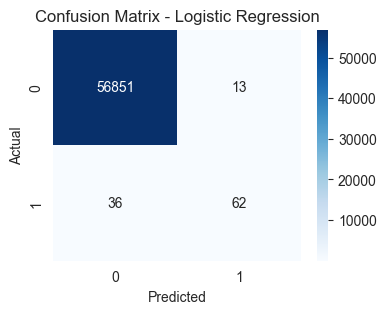

ROC-AUC: 0.9605494455801453

--- Random Forest ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.83      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962



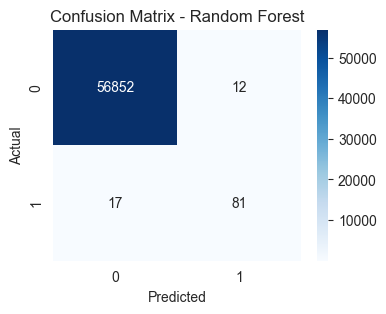

ROC-AUC: 0.9754222032088018

--- XGBoost ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.39      0.87      0.54        98

    accuracy                           1.00     56962
   macro avg       0.69      0.93      0.77     56962
weighted avg       1.00      1.00      1.00     56962



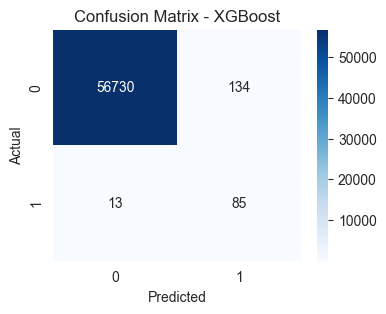

ROC-AUC: 0.9807517829866893


In [9]:

# ===== Evaluate baseline models =====
eval_print('Logistic Regression', y_test, y_pred_lr, lr_pipe)
eval_print('Random Forest', y_test, y_pred_rf, rf_pipe)
if y_pred_xgb is not None:
    eval_print('XGBoost', y_test, y_pred_xgb, xgb_pipe)


In [10]:

# ===== Model Comparison Table =====
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def evaluate_model_summary(name, y_true, y_pred):
    return {
        'Model': name,
        'Accuracy': round(accuracy_score(y_true, y_pred), 6),
        'Precision (Class 1)': round(precision_score(y_true, y_pred, zero_division=0), 6),
        'Recall / TPR (Class 1)': round(recall_score(y_true, y_pred, zero_division=0), 6),
        'F1-Score (Class 1)': round(f1_score(y_true, y_pred, zero_division=0), 6),
        'Confusion Matrix': confusion_matrix(y_true, y_pred).tolist()
    }

results = []
results.append(evaluate_model_summary('Logistic Regression', y_test, y_pred_lr))
results.append(evaluate_model_summary('Random Forest', y_test, y_pred_rf))
if y_pred_xgb is not None:
    results.append(evaluate_model_summary('XGBoost (Final)', y_test, y_pred_xgb))

comp_df = pd.DataFrame(results).set_index('Model')
display(comp_df)


,Accuracy,Precision (Class 1),Recall / TPR (Class 1),F1-Score (Class 1),Confusion Matrix
Model,,,,,
Logistic Regression,0.999140,0.826667,0.632653,0.716763,"[[56851, 13], [36, 62]]"
Random Forest,0.999491,0.870968,0.826531,0.848168,"[[56852, 12], [17, 81]]"
XGBoost (Final),0.997419,0.388128,0.867347,0.536278,"[[56730, 134], [13, 85]]"


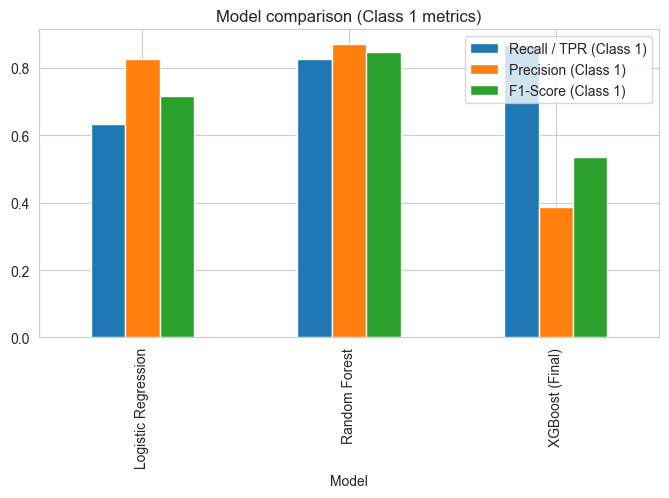

In [11]:

# ===== Plot Comparison Bars =====
comp_plot = comp_df[['Recall / TPR (Class 1)', 'Precision (Class 1)', 'F1-Score (Class 1)']].plot.bar(figsize=(8,4))
plt.title('Model comparison (Class 1 metrics)')
plt.show()


Starting XGBoost pipeline randomized search... (fast)
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best params: {'model__subsample': 0.8, 'model__n_estimators': 200, 'model__max_depth': 5, 'model__learning_rate': 0.1, 'model__colsample_bytree': 1.0}

Tuned XGBoost evaluation:

--- XGBoost (Tuned) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.44      0.86      0.58        98

    accuracy                           1.00     56962
   macro avg       0.72      0.93      0.79     56962
weighted avg       1.00      1.00      1.00     56962



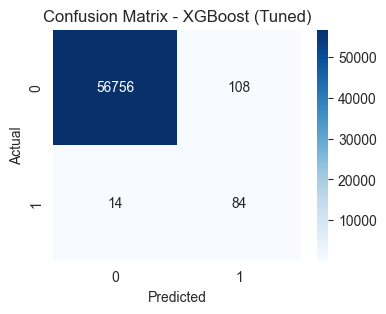

ROC-AUC: 0.9789978667325118


In [12]:

# ===== Fast Hyperparameter Tuning (Pipeline) =====
from sklearn.model_selection import RandomizedSearchCV

# Only run tuning for pipelines if available
if xgb_pipe is None:
    print('XGBoost pipeline not available. Skipping tuning.')
else:
    xgb_param_grid = {
        'model__n_estimators': [100,200,300],
        'model__max_depth': [3,4,5],
        'model__learning_rate': [0.01,0.05,0.1],
        'model__subsample': [0.7,0.8,1.0],
        'model__colsample_bytree': [0.7,0.8,1.0]
    }
    xgb_search = RandomizedSearchCV(
        estimator=xgb_pipe,
        param_distributions=xgb_param_grid,
        n_iter=8,
        scoring='f1',
        cv=3,
        verbose=1,
        n_jobs=-1,
        random_state=RANDOM_STATE
    )
    print('Starting XGBoost pipeline randomized search... (fast)')
    xgb_search.fit(X_train, y_train)
    print('Best params:', xgb_search.best_params_)
    best_xgb_pipe = xgb_search.best_estimator_
    # Evaluate tuned pipeline
    y_pred_xgb_tuned = best_xgb_pipe.predict(X_test)
    print('\nTuned XGBoost evaluation:')
    eval_print('XGBoost (Tuned)', y_test, y_pred_xgb_tuned, best_xgb_pipe)


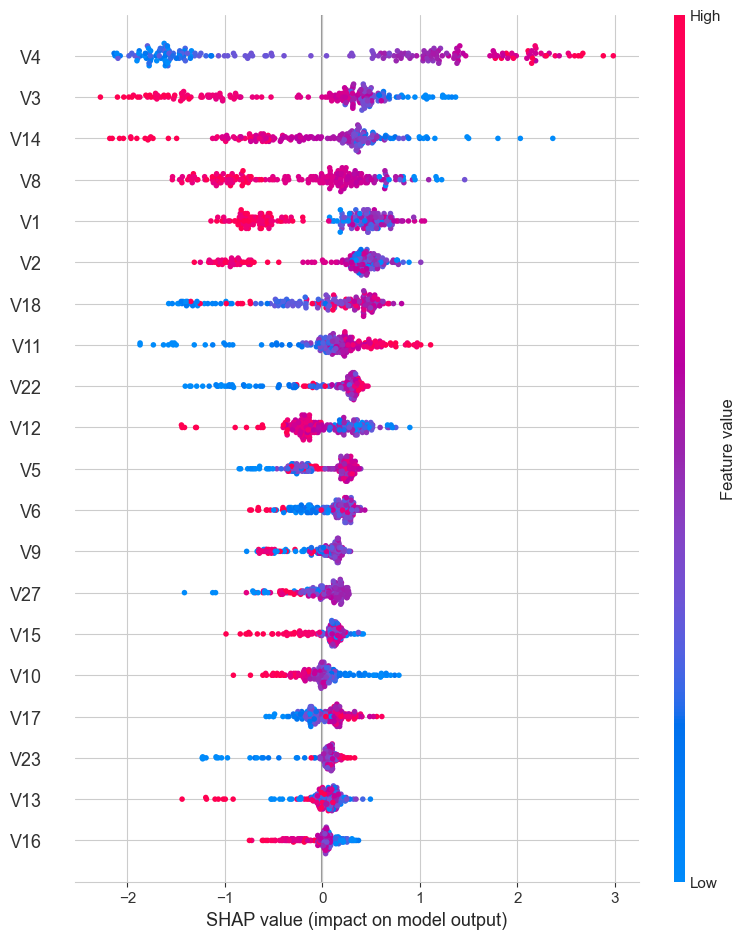

In [13]:

# ===== SHAP explainability =====
try:
    import shap
    shap_installed = True
except Exception:
    shap_installed = False
    print('shap not installed; install shap to enable explainability.')

if shap_installed:
    # select model for explanation
    model_for_shap = None
    if 'best_xgb_pipe' in globals():
        model_for_shap = best_xgb_pipe
    elif xgb_pipe is not None:
        model_for_shap = xgb_pipe
    else:
        print('No XGBoost pipeline available for SHAP.')
    
    if model_for_shap is not None:
        # Extract internal estimator for SHAP (the trained model inside pipeline)
        final_model = model_for_shap.named_steps['model'] if hasattr(model_for_shap, 'named_steps') else model_for_shap
        # Use a sample for SHAP speed
        sample = X_test.sample(n=min(200, len(X_test)), random_state=RANDOM_STATE)
        try:
            explainer = shap.Explainer(final_model, shap.sample(X_train, 200))
            shap_values = explainer(sample)
            shap.summary_plot(shap_values.values, sample, feature_names=sample.columns)
        except Exception as e:
            print('SHAP failed:', e)


In [14]:

# ===== Save models for deployment =====
final_pipeline = None
if 'best_xgb_pipe' in globals():
    final_pipeline = best_xgb_pipe
elif xgb_pipe is not None:
    final_pipeline = xgb_pipe

if final_pipeline is not None:
    joblib.dump(final_pipeline, os.path.join(MODEL_DIR, 'final_pipeline.joblib'))
    print('Saved final pipeline to', os.path.join(MODEL_DIR, 'final_pipeline.joblib'))

# Also save comparison baseline models (LR and RF pipelines)
joblib.dump(lr_pipe, os.path.join(MODEL_DIR, 'lr_pipe.joblib'))
joblib.dump(rf_pipe, os.path.join(MODEL_DIR, 'rf_pipe.joblib'))
print('Saved LR and RF pipelines for comparison.')


Saved final pipeline to models\final_pipeline.joblib
Saved LR and RF pipelines for comparison.



## Streamlit deployment
A `streamlit_app.py` file is included in the project root. Run with:
```
streamlit run streamlit_app.py
```
It will load `models/final_pipeline.joblib` (if present) and perform batch/single predictions.
